In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score,accuracy_score,confusion_matrix,precision_score,f1_score,roc_curve,auc,multilabel_confusion_matrix
import pandas as pd
import optuna
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train=pd.read_csv(r"D:\ML Project\Data Splits\X_train.csv")
X_val=pd.read_csv(r"D:\ML Project\Data Splits\X_val.csv")
X_test=pd.read_csv(r"D:\ML Project\Data Splits\X_test.csv")

Y_train=pd.read_csv(r"D:\ML Project\Data Splits\Y_train.csv")['class']
Y_val=pd.read_csv(r"D:\ML Project\Data Splits\Y_val.csv")['class']
Y_test=pd.read_csv(r"D:\ML Project\Data Splits\Y_test.csv")['class']

In [3]:
# n_estimators=list(range(50,350,50))
# criterion=['gini','entropy']
# max_depth=list(range(3,11))
# max_features=['sqrt','log2']
# min_samples_leaf=list(range(1,6,1))
# min_samples_split=list(range(2,11,1))
# bootstrap=[True,False]

In [4]:
def objective(trial):
    n_estimators=trial.suggest_int('n_estimators',50,300)
    criterion=trial.suggest_categorical('criterion',['gini','entropy'])
    max_depth=trial.suggest_int('max_depth',3,10)
    max_features=trial.suggest_categorical('max_features',['sqrt','log2'])
    min_samples_leaf=trial.suggest_int('min_samples_leaf',1,5)
    min_samples_split=trial.suggest_int('min_samples_split',2,10)
    bootstrap=trial.suggest_categorical('bootstrap',[True,False]) 

    model=RandomForestClassifier(n_estimators=n_estimators,max_depth=max_depth,max_features=max_features,min_samples_leaf=min_samples_leaf,min_samples_split=min_samples_split,bootstrap=bootstrap,criterion=criterion,random_state=50)
    model.fit(X_train,Y_train)
    Y_val_pred=model.predict(X_val)
    accuracy_val=accuracy_score(Y_val,Y_val_pred)

    return accuracy_val


study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)

# direction='maximize' since we are working on acuracy which needs to be maximized


[I 2026-05-25 12:42:10,917] A new study created in memory with name: no-name-557a4245-1289-4e79-aba8-000978e09677
[I 2026-05-25 12:44:49,249] Trial 0 finished with value: 0.9895 and parameters: {'n_estimators': 183, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 7, 'bootstrap': True}. Best is trial 0 with value: 0.9895.
[I 2026-05-25 12:45:26,634] Trial 1 finished with value: 0.9898 and parameters: {'n_estimators': 53, 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 6, 'bootstrap': True}. Best is trial 1 with value: 0.9898.
[I 2026-05-25 12:46:38,716] Trial 2 finished with value: 0.9904 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 3, 'bootstrap': True}. Best is trial 2 with value: 0.9904.
[I 2026-05-25 12:48:39,679] Trial 3 finished with value: 0.9873 and parameters: {'n_es

In [5]:
optuna_RF = study.trials_dataframe()
optuna_RF.to_csv(r"D:\ML Project\Model_Tuned_Parameter_data\Optuna_RF.csv", index=False)

In [6]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\RF.json", "w") as f:
    input=study.best_trial.params
    input['Accuracy']=study.best_trial.value
    json.dump(input, f)

In [7]:
print(f'Validation best accuracy: {study.best_trial.value}')
print(f'Validation best parameters: {study.best_trial.params}')

Validation best accuracy: 0.9916
Validation best parameters: {'n_estimators': 99, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'bootstrap': False}


In [8]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\RF.json", "r") as f:
    loaded_dict = json.load(f)

params = dict(list(loaded_dict.items())[:-1])
validation_accuracy=loaded_dict['Accuracy']

In [9]:
model_best=RandomForestClassifier(**params,random_state=50)  # *8 unpacks the dictionary and allows us to pass the dictionary keys as keywords (parameter keywords) in the function

# Dictionary Unpacking in Function CallsThe ** operator allows you to take key-value pairs from a dictionary and pass them as named keyword arguments to a function. Experts on Stack Overflow explain that this enables dynamic argument handling.pythondef greet(name, age):
#     print(f"Hello {name}, you are {age} years old.")

# data = {"name": "Alice", "age": 25}
# greet(**data)  # Equivalent to greet(name="Alice", age=25)
# Use code with caution.3. Collecting Arguments (**kwargs)In a function definition, ** collects any number of keyword arguments into a single dictionary, typically named kwargs. A guide on Medium highlights how this provides a shortcut for accepting flexible inputs.pythondef show_info(**kwargs):
#     for key, value in kwargs.items():
#         print(f"{key}: {value}")

# show_info(city="New York", job="Developer") 
# # kwargs becomes {'city': 'New York', 'job': 'Developer'}
# Use code with caution.4. Merging Dictionaries (Python 3.5+)You can use ** inside a dictionary literal to merge multiple dictionaries into one.pythondict1 = {"a": 1}
# dict2 = {"b": 2}
# merged = {**dict1, **dict2}  # Output: {'a': 1, 'b': 2}


model_best.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",99
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [10]:
Y_train_pred=model_best.predict(X_train)

Accuracy_train=accuracy_score(Y_train,Y_train_pred)

Accuracy_train       # Train Accuracy

0.99385

## Test Set Analysis ###########

In [11]:
Y_test_pred=model_best.predict(X_test)

In [12]:
Accuracy_test=accuracy_score(Y_test,Y_test_pred)
Accuracy_test                                 # Test Accuracy

0.9907

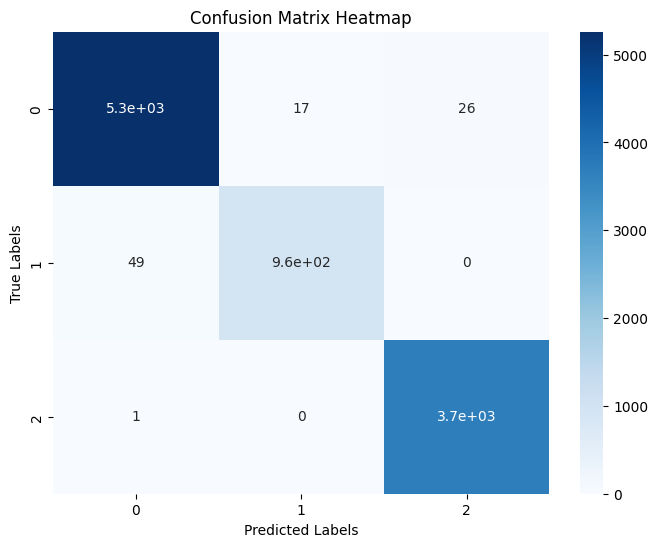

In [13]:
conf_matrix=confusion_matrix(Y_test,Y_test_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,annot=True,cmap='Blues')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [14]:
### Recall

Macro_average_recall=recall_score(Y_test,Y_test_pred,average='macro')
Per_class_recall=recall_score(Y_test,Y_test_pred,average=None)

Macro_average_recall   ## Macro Recall and accuracy both are high. So class imbalance is not a problem

0.9809713849404686

In [15]:
Per_class_recall    ## Class imbalance is not an issue as per recall since per class recall for all 3 classes is very high.

array([0.99189291, 0.95129225, 0.999729  ])

In [16]:
## Precision

Macro_average_precision=precision_score(Y_test,Y_test_pred,average='macro')
Per_class_precision=precision_score(Y_test,Y_test_pred,average=None)

Macro_average_precision   ## Macro Average Precision is also very high

0.9887110414103922

In [17]:
Per_class_precision  ## Even per class precision is also very high

array([0.99058558, 0.9825462 , 0.99300135])

In [18]:
## F1 score

Macro_average_f1_score=f1_score(Y_test,Y_test_pred,average='macro')
Per_class_f1_score=f1_score(Y_test,Y_test_pred,average=None)

Macro_average_f1_score   ## Macro Average Precision is also very high

0.9847530982190031

In [19]:
Per_class_f1_score

array([0.99123881, 0.96666667, 0.99635381])

In [20]:
## Sensitivity and Specificity

mcm = multilabel_confusion_matrix(Y_test,Y_test_pred)

tn = mcm[:, 0, 0]
fp = mcm[:, 0, 1]
fn = mcm[:, 1, 0]
tp = mcm[:, 1, 1]

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

sensitivity

array([0.99189291, 0.95129225, 0.999729  ])

In [21]:
specificity

array([0.98935264, 0.99810985, 0.99587956])

In [22]:
Metrics={'Training Accuracy':Accuracy_train,'Validation Accuracy (Post Optuna Tuning)':validation_accuracy,'Test Accuracy':Accuracy_test,'Macro Average Recall':Macro_average_recall,
         'Per Class Recall':Per_class_recall,'Macro Average Precision':Macro_average_precision,'Per Class Precision':Per_class_precision,'Macro Average F1 Score':Macro_average_f1_score,
         'Per Class F1 Score':Per_class_f1_score,'Sensitivity':sensitivity,'Specificity':specificity}

Metrics=pd.Series(Metrics)

In [23]:
Metrics

Training Accuracy                                                                     0.99385
Validation Accuracy (Post Optuna Tuning)                                               0.9916
Test Accuracy                                                                          0.9907
Macro Average Recall                                                                 0.980971
Per Class Recall                            [0.9918929110105581, 0.9512922465208747, 0.999...
Macro Average Precision                                                              0.988711
Per Class Precision                         [0.9905855771041235, 0.9825462012320328, 0.993...
Macro Average F1 Score                                                               0.984753
Per Class F1 Score                          [0.991238813000471, 0.9666666666666667, 0.9963...
Sensitivity                                 [0.9918929110105581, 0.9512922465208747, 0.999...
Specificity                                 [0.9893526405451

In [24]:
Metrics.to_csv(r'D:\ML Project\Model_Metrics\Random_Forest.csv',header=False)